# Customer Segmentation Analysis

## Setup and Data Loading

The dataset is provided as an Excel file with two sheets, covering 2009-2010 and 2010-2011. Both sheets are loaded and combined into a single DataFrame before any inspection begins.

In [1]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import os

file_path = r'C:\Users\ADMIN\OneDrive\Customer_Segmentation\online_retail_II.xlsx'

sheet_2009_2010 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
sheet_2010_2011 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

df = pd.concat([sheet_2009_2010, sheet_2010_2011], ignore_index=True)
print("Done")

Done


## Data Inspection

Before any cleaning decisions are made, the raw dataset is inspected for its shape, structure, data types, and missing values.

In [3]:
df.shape

(1067371, 8)

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [6]:
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
df['Customer ID'].nunique()

5942

In [9]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

## Identifying Data Quality Issues

Several anomalies are checked next: negative quantities (likely returns or cancellations), non-positive prices, and cancelled invoices (marked with a "C" prefix). Investigated individually before deciding how to handle it.

In [10]:
(df['Quantity'] < 0).sum()

np.int64(22950)

In [11]:
(df['Price'] <= 0).sum()

np.int64(6207)

In [12]:
df['Invoice'].astype(str).str.startswith('C').sum()

np.int64(19494)

## Investigating the Anomalies

The rows behind each anomaly are reviewed first, so cleaning decisions are based on what the data really contains.

In [13]:
df.loc[df['Quantity'] < 0, ['Invoice', 'Quantity', 'Price']].head(10)

,Invoice,Quantity,Price
178,C489449,-12,2.95
179,C489449,-6,1.65
180,C489449,-4,4.25
181,C489449,-6,2.10
182,C489449,-12,2.95
183,C489449,-12,1.25
184,C489449,-12,1.25
185,C489449,-24,0.85
186,C489449,-12,2.95
196,C489459,-3,4.25


In [14]:
df['Invoice'].astype(str).str.startswith('C').value_counts()

Invoice
False    1047877
True       19494
Name: count, dtype: int64

In [15]:
df['Price'].describe()

count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64

In [16]:
df.loc[df['Price'] <= 0, ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID']].head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer ID
263,489464,21733,85123a mixed,-96,0.0,NaN
283,489463,71477,short,-240,0.0,NaN
284,489467,85123A,21733 mixed,-192,0.0,NaN
470,489521,21646,NaN,-50,0.0,NaN
3114,489655,20683,NaN,-44,0.0,NaN
3161,489659,21350,NaN,230,0.0,NaN
3162,489660,35956,lost,-1043,0.0,NaN
3168,489663,35605A,damages,-117,0.0,NaN
3731,489781,84292,NaN,17,0.0,NaN
4296,489806,18010,NaN,-770,0.0,NaN


In [17]:
df.loc[df['Price'] > 1000, ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID']].head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer ID
9307,C490129,M,Manual,-1,1998.49,15482.0
22960,491176,M,Manual,1,1213.02,13091.0
56523,C494477,M,Manual,-1,1747.62,NaN
62735,494918,DOT,DOTCOM POSTAGE,1,1081.70,NaN
65448,C495234,M,Manual,-1,1193.89,14156.0
65449,495235,M,Manual,1,1193.89,14156.0
71077,495798,ADJUST,Adjustment by john on 26/01/2010 17,1,5117.03,NaN
74356,496115,M,Manual,1,8985.60,17949.0
74357,C496116,M,Manual,-1,8985.60,17949.0
74358,C496118,M,Manual,-1,1065.54,17940.0


In [18]:
df.loc[(df['Quantity'] < 0) & (~df['Invoice'].astype(str).str.startswith('C')),
       ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID']].head(10)

,Invoice,StockCode,Description,Quantity,Price,Customer ID
263,489464,21733,85123a mixed,-96,0.0,NaN
283,489463,71477,short,-240,0.0,NaN
284,489467,85123A,21733 mixed,-192,0.0,NaN
470,489521,21646,NaN,-50,0.0,NaN
3114,489655,20683,NaN,-44,0.0,NaN
3162,489660,35956,lost,-1043,0.0,NaN
3168,489663,35605A,damages,-117,0.0,NaN
4296,489806,18010,NaN,-770,0.0,NaN
4538,489820,21133,invcd as 84879?,-720,0.0,NaN
4566,489821,85049G,NaN,-240,0.0,NaN


In [19]:
df.loc[
    (df['Quantity'] < 0) &
    (~df['Invoice'].astype(str).str.startswith('C')),
    'Description'
].value_counts().head(20)

Description
check                     123
damages                    84
?                          83
damaged                    78
missing                    27
sold as set on dotcom      20
Damaged                    17
smashed                     9
thrown away                 9
Unsaleable, destroyed.      9
dotcom                      8
damages?                    7
??                          7
crushed                     6
given away                  6
MIA                         5
Damages                     5
counted                     5
checked                     5
wet damaged                 5
Name: count, dtype: int64

In [20]:
df['Customer ID'].isna().mean() * 100

np.float64(22.766872999172733)

In [21]:
df['Customer ID'].value_counts().describe()

count     5942.000000
mean       138.735106
std        359.689585
min          1.000000
25%         21.000000
50%         53.000000
75%        144.000000
max      13097.000000
Name: count, dtype: float64

In [22]:
customer_invoice_counts = df.groupby('Customer ID')['Invoice'].nunique()

customer_invoice_counts.describe()

count    5942.000000
mean        7.552339
std        15.972262
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max       510.000000
Name: Invoice, dtype: float64

In [23]:
df.duplicated(keep=False)

0          False
1          False
2          False
3          False
4          False
           ...  
1067366    False
1067367    False
1067368    False
1067369    False
1067370    False
Length: 1067371, dtype: bool

In [24]:
df[df.duplicated(keep=False)].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [25]:
df[df.duplicated(keep=False)]['Invoice'].nunique()

5391

In [26]:
# Check whether any negative-quantity, non-cancelled rows have a valid Customer ID.
# Result is empty, meaning these rows always lack a Customer ID, so they will
# already be excluded once the missing-Customer-ID filter is applied.

df.loc[
    (df['Quantity'] < 0) &
    (~df['Invoice'].astype(str).str.startswith('C')) &
    (df['Customer ID'].notna()),
    'Customer ID'
].shape

(0,)

In [27]:
df.loc[
    df['Invoice'].astype(str).str.startswith('C') &
    df['Customer ID'].notna(),
    ['Invoice', 'Quantity', 'Price', 'Customer ID']
].shape

(18744, 4)

In [28]:
cancellation_data = df[df['Invoice'].astype(str).str.startswith('C')]

cancellation_data['TransactionValue'] = (
    cancellation_data['Quantity'] * cancellation_data['Price']
)

cancellation_data[['Quantity', 'Price', 'TransactionValue']].describe()

,Quantity,Price,TransactionValue
count,19494.000000,19494.000000,19494.000000
mean,-25.186827,44.872221,-78.314756
std,805.104908,596.335291,1459.635817
min,-80995.000000,0.010000,-168469.600000
25%,-6.000000,1.450000,-17.850000
50%,-2.000000,2.950000,-8.950000
75%,-1.000000,6.750000,-3.750000
max,1.000000,38970.000000,373.570000


In [29]:
(cancellation_data['TransactionValue'] > 0).sum()

np.int64(1)

## Building the Valid Sales Dataset

Based on the checks above, a transaction is treated as valid for RFM purposes if it is not a cancellation, has a positive quantity, has a positive price, and has a known Customer ID.

In [30]:
valid_sales = df.loc[
    (~df['Invoice'].astype(str).str.startswith('C')) &
    (df['Quantity'] > 0) &
    (df['Price'] > 0) &
    (df['Customer ID'].notna())
].copy()

print("Original rows:", len(df))
print("Valid sales rows:", len(valid_sales))
print("Rows removed:", len(df) - len(valid_sales))
print("Percentage retained:", round(len(valid_sales) / len(df) * 100, 2), "%")

Original rows: 1067371
Valid sales rows: 805549
Rows removed: 261822
Percentage retained: 75.47 %


In [31]:
valid_sales.duplicated().sum()

np.int64(26124)

In [32]:
valid_sales['Invoice'].nunique()

36969

In [33]:
# Inspect exact duplicate sales lines
valid_sales[valid_sales.duplicated(keep=False)] \
    .sort_values(['Invoice', 'StockCode']) \
    .head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom


In [34]:
# Measure the impact of removing exact duplicate sales rows
duplicate_rows = valid_sales.duplicated(keep='first').sum()

duplicate_value = (
    valid_sales.loc[valid_sales.duplicated(keep='first'), 'Quantity']
    * valid_sales.loc[valid_sales.duplicated(keep='first'), 'Price']
).sum()

print("Exact duplicate rows:", duplicate_rows)
print("Value contributed by duplicate rows:", round(duplicate_value, 2))

Exact duplicate rows: 26124
Value contributed by duplicate rows: 368624.91


## Removing Duplicate Transactions

Exact duplicate transaction rows can inflate customer purchase value without adding additional purchases. Since Frequency is based on unique invoices, these duplicates mainly affect the Monetary measure.

The duplicate records identified during data validation are therefore removed before constructing the final RFM dataset.

In [35]:
# Remove exact duplicate transaction rows
valid_sales = valid_sales.drop_duplicates().copy()

print("Rows after removing exact duplicates:", len(valid_sales))
print("Duplicates remaining:", valid_sales.duplicated().sum())

Rows after removing exact duplicates: 779425
Duplicates remaining: 0


## Identifying Non-Product Transactions

Some records in the dataset represent administrative or service-related transactions rather than actual product purchases,including them in customer purchase value could distort the RFM analysis.

We will first identify the stock codes and descriptions associated with these transactions before deciding which records should be excluded.

In [36]:
# Review the most common stock codes in the cleaned sales data
valid_sales['StockCode'].value_counts().head(20)

StockCode
85123A    5023
22423     3335
85099B    3296
84879     2692
20725     2609
21212     2557
47566     2098
20727     2045
22383     2039
21034     1950
21232     1935
22382     1935
22384     1874
21754     1852
22139     1848
20914     1821
22469     1821
20728     1820
84991     1813
POST      1803
Name: count, dtype: int64

## Review Non-Product and Administrative Transactions

The stockcode frequency check shows that some non-product transaction codes are present alongside regular merchandise codes. These may represent postage, manual adjustments, bank charges, or other administrative activities.

Because RFM Monetary is intended to represent customer purchasing value, these records need to be reviewed before the final RFM calculation.

In [37]:
# Inspect records using common non-product transaction codes
codes = ['M', 'POST', 'DOT', 'ADJUST', 'BANK CHARGES', 'C2', 'CRUK']

valid_sales[
    valid_sales['StockCode'].astype(str).str.upper().isin(codes)
][['StockCode', 'Description', 'Quantity', 'Price', 'Customer ID']].head(30)

,StockCode,Description,Quantity,Price,Customer ID
89,POST,POSTAGE,3,18.00,12682.0
126,POST,POSTAGE,1,141.00,12636.0
173,POST,POSTAGE,1,130.00,12362.0
625,POST,POSTAGE,6,18.00,12533.0
1244,POST,POSTAGE,4,18.00,12490.0
6406,POST,POSTAGE,3,18.00,12437.0
9292,C2,CARRIAGE,1,50.00,14156.0
10279,POST,POSTAGE,7,18.00,12714.0
10344,POST,POSTAGE,3,18.00,12759.0
11193,POST,POSTAGE,4,28.00,12510.0


## Exclude Non-Product Transactions

The review identified transaction codes representing postage, carriage, manual entries, and bank charges rather than merchandise purchases. These records are excluded from the RFM transaction population so that Monetary reflects customers' product purchase value rather than administrative or service charges.

In [38]:
# Remove non-product transaction codes
codes = ['M', 'POST', 'DOT', 'ADJUST', 'BANK CHARGES', 'C2', 'CRUK']

valid_sales = valid_sales[
    ~valid_sales['StockCode'].astype(str).str.upper().isin(codes)
].copy()

print("Rows after removing non-product transactions:", len(valid_sales))

Rows after removing non-product transactions: 776614


In [39]:
# Verify that non-product transaction codes have been removed
remaining_non_product = valid_sales[
    valid_sales['StockCode'].astype(str).str.upper().isin(codes)
]

print("Non-product rows remaining:", len(remaining_non_product))

Non-product rows remaining: 0


### RFM Reference Date

Recency measures how long it has been since a customer's last purchase.


In [40]:
# Set the reference date for Recency
reference_date = valid_sales['InvoiceDate'].max().normalize() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2011-12-10 00:00:00


### Calculate Recency

Recency is the number of days since each customer's last purchase.

In [41]:
# Calculate each customer's Recency
recency = valid_sales.groupby('Customer ID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (reference_date - recency['InvoiceDate']).dt.days

print("Recency calculated.")
print(recency.head())

Recency calculated.
   Customer ID         InvoiceDate  Recency
0      12346.0 2011-01-18 10:01:00      325
1      12347.0 2011-12-07 15:52:00        2
2      12348.0 2011-09-25 13:13:00       75
3      12349.0 2011-11-21 09:51:00       18
4      12350.0 2011-02-02 16:01:00      310


### Calculate Frequency

Frequency is the number of unique invoices for each customer.

In [42]:
# Count unique purchases for each customer
frequency = valid_sales.groupby('Customer ID')['Invoice'].nunique().reset_index()

frequency.columns = ['Customer ID', 'Frequency']

print("Frequency calculated.")
print(frequency.head())

Frequency calculated.
   Customer ID  Frequency
0      12346.0         12
1      12347.0          8
2      12348.0          5
3      12349.0          3
4      12350.0          1


### Calculate Monetary

Monetary is the total value of a customer's purchases.

In [43]:
# Calculate total purchase value for each customer
valid_sales['TransactionValue'] = valid_sales['Quantity'] * valid_sales['Price']

monetary = valid_sales.groupby('Customer ID')['TransactionValue'].sum().reset_index()

monetary.columns = ['Customer ID', 'Monetary']

print("Monetary calculated.")
print(monetary.head())

Monetary calculated.
   Customer ID  Monetary
0      12346.0  77556.46
1      12347.0   4921.53
2      12348.0   1658.40
3      12349.0   3678.69
4      12350.0    294.40


### Combining the RFM Metrics

Combine Recency, Frequency, and Monetary into one table.

In [44]:
# Combine the three RFM metrics by Customer ID
rfm = recency.merge(frequency, on='Customer ID').merge(monetary, on='Customer ID')

print("RFM table created.")
print(rfm.head())

RFM table created.
   Customer ID         InvoiceDate  Recency  Frequency  Monetary
0      12346.0 2011-01-18 10:01:00      325         12  77556.46
1      12347.0 2011-12-07 15:52:00        2          8   4921.53
2      12348.0 2011-09-25 13:13:00       75          5   1658.40
3      12349.0 2011-11-21 09:51:00       18          3   3678.69
4      12350.0 2011-02-02 16:01:00      310          1    294.40


### RFM Descriptive Statistics

Review the distribution of the RFM variables before preprocessing.

In [45]:
# Review the RFM variables
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,5852.000000,5852.000000,5852.000000
mean,199.732399,6.256323,2916.940820
std,208.523287,12.754412,14307.285201
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,339.575000
50%,95.000000,3.000000,856.020000
75%,379.000000,7.000000,2241.030000
max,738.000000,373.000000,580987.040000


### RFM Distributions

Visualize the distributions of Recency, Frequency, and Monetary.

array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

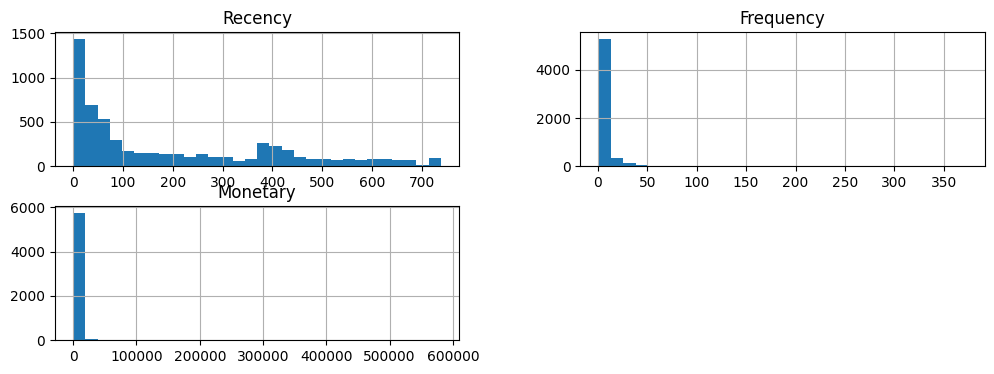

In [46]:
# Plot the RFM distributions
rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=30, figsize=(12, 4))

## RFM Preprocessing

### Assess Skewness

Skewness is calculated to determine whether Recency, Frequency, and Monetary are strongly asymmetric. This helps decide whether transformation is needed before scaling.

In [47]:
# Quantify skew numerically
rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency       0.894303
Frequency    12.033662
Monetary     25.329291
dtype: float64

### Log Transformation

Frequency and Monetary show substantial right skewness. A log1p transformation is applied to these two variables to compress extreme values and reduce the influence of unusually frequent or high value customers during clustering.

In [48]:
import numpy as np

rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

# Check whether the transformation reduced the skewness
rfm[['Frequency_log', 'Monetary_log']].skew()

Frequency_log    1.001276
Monetary_log     0.273559
dtype: float64

In [49]:
# Install scikit-learn for KMeans and StandardScaler
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Feature Scaling

After reducing skewness, the RFM features are standardized so that Recency, Frequency, and Monetary contribute comparably to the distance calculations used by K-Means.

In [50]:
from sklearn.preprocessing import StandardScaler

# Select the final features for clustering
features = rfm[['Recency', 'Frequency_log', 'Monetary_log']]

# Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

# Convert the scaled values into a labeled DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
)

rfm_scaled.describe()

,Recency_scaled,Frequency_scaled,Monetary_scaled
count,5.852000e+03,5.852000e+03,5.852000e+03
mean,-6.799452e-17,1.517735e-17,2.768348e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.579240e-01,-1.057512e+00,-3.938182e+00
25%,-8.380231e-01,-1.057512e+00,-7.086392e-01
50%,-5.023005e-01,-1.995065e-01,-3.994735e-02
75%,8.597741e-01,6.584992e-01,6.568956e-01
max,2.581551e+00,5.417766e+00,4.683824e+00


## Choosing the Number of Clusters

### Elbow Method and Silhouette Analysis

Several values of K are evaluated to identify a suitable number of customer segments. The Elbow Method assesses the reduction in within cluster variation, while the Silhouette Score evaluates cluster separation and cohesion.

In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(rfm_scaled, cluster_labels))

results = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia_values,
    'Silhouette_Score': silhouette_values
})

results

,K,Inertia,Silhouette_Score
0,2,8854.957730,0.418186
1,3,5692.591621,0.401710
2,4,4454.554424,0.361080
3,5,3627.615391,0.365066
4,6,3064.363488,0.348747
5,7,2723.446016,0.335815
6,8,2461.802554,0.315731
7,9,2278.229427,0.312373
8,10,2125.556916,0.300181


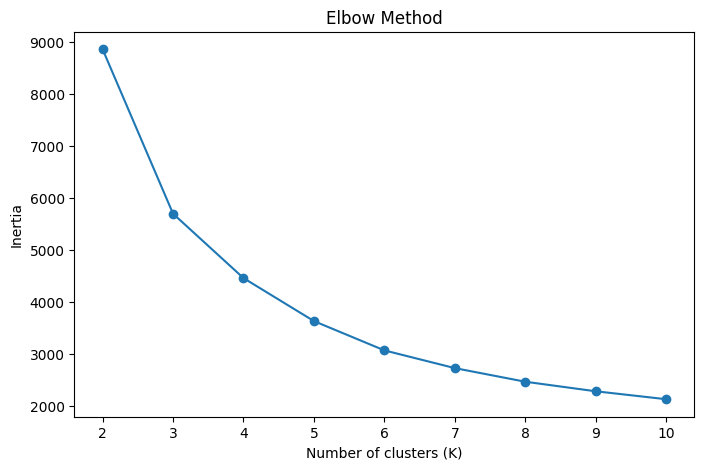

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

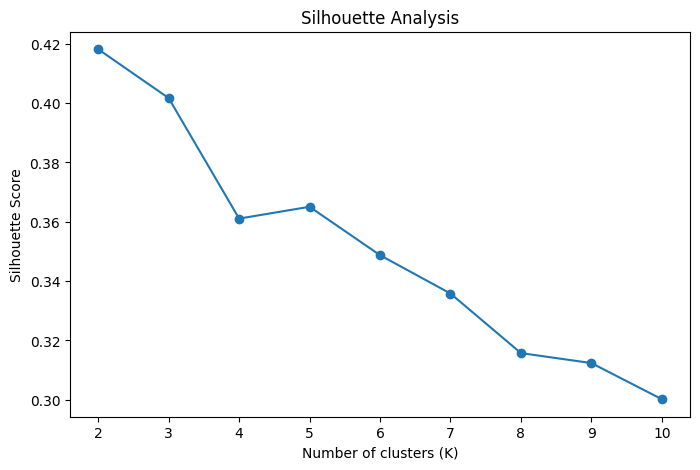

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_values, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

## Selecting K = 5

The elbow curve did not show one sharp bend, the slowdown in inertia reduction was gradual between K=4 and K=5.: it declines steadily as K increases, except for a local increase from K=4 (0.361) to K=5 (0.365), the only place the trend reverses. Both signals pointing to the same value supports K=5 as the better-separated choice over K=4.

In [54]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# Check cluster sizes first, before anything else
rfm['Cluster'].value_counts().sort_index()

Cluster
0     845
1    1688
2     890
3    1350
4    1079
Name: count, dtype: int64

## Clustering Centroids in Original Units

K-Means was fit on scaled, log transformed values. Recomputing the mean of the original
Recency, Frequency, and Monetary columns per cluster translates the
result back to be interpretable.

In [55]:
# Compute average Recency, Frequency, and Monetary per cluster, using the
# original (untransformed) columns, not the scaled ones used for fitting
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

# Attach cluster sizes so the profile table is self-contained
cluster_profile['Count'] = rfm['Cluster'].value_counts().sort_index()

cluster_profile

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,394.29,3.35,1262.16,845
1,63.52,5.75,1937.22,1688
2,41.46,22.98,13379.13,890
3,97.53,1.73,412.84,1350
4,518.88,1.19,248.95,1079


## Verifying Cluster 3 as New Customers

Cluster 3's low Recency and Frequency could describe either a new customer or a long-time customer who buys rarely. Checking each cluster's median first-purchase date distinguishes between the two.

In [56]:
# Check whether Cluster 3 customers are actually recent arrivals, not just infrequent buyers
first_purchase = valid_sales.groupby('Customer ID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['Customer ID', 'FirstPurchase']

rfm_check = rfm.merge(first_purchase, on='Customer ID')
rfm_check.groupby('Cluster')['FirstPurchase'].median()

Cluster
0   2010-04-19 14:09:00
1   2010-06-14 01:12:30
2   2010-01-09 13:13:00
3   2011-06-19 15:09:00
4   2010-06-17 08:20:00
Name: FirstPurchase, dtype: datetime64[us]

## Cluster Visualizations

Scatter plots are used to check whether the five clusters visually separate as expected, and to confirm the outlier behavior identified in Cluster 2. Both axes use a log scale where needed, since a small number of extreme values would otherwise compress the rest of the clusters into an unreadable clump.

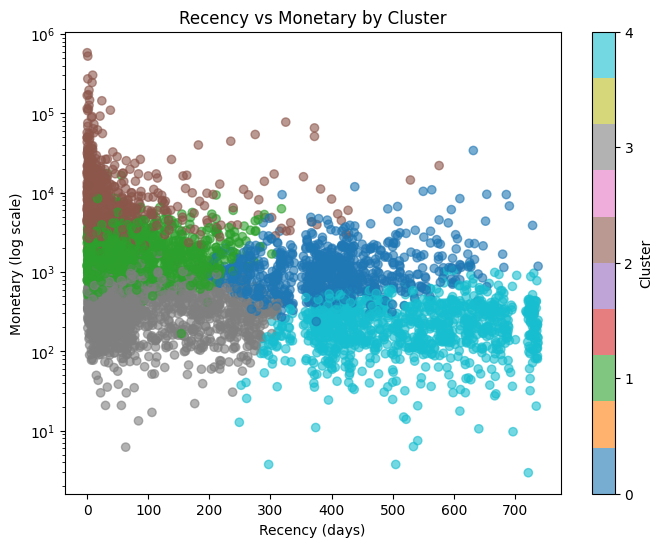

In [57]:
# Recency vs Monetary, log scale on Monetary to prevent outliers from
# squashing the rest of the clusters into an unreadable clump
plt.figure(figsize=(8,6))
scatter = plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='tab10', alpha=0.6)
plt.yscale('log')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (log scale)')
plt.title('Recency vs Monetary by Cluster')
plt.colorbar(scatter, label='Cluster', ticks=[0,1,2,3,4])
plt.show()

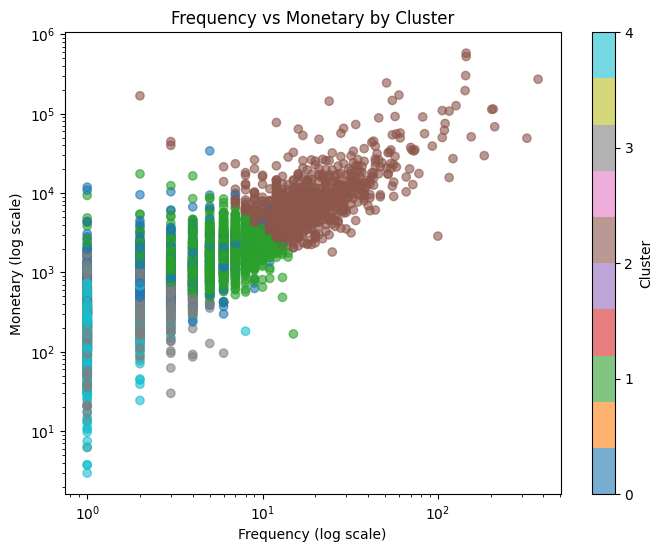

In [58]:
# Frequency vs Monetary, log scale on both axes

plt.figure(figsize=(8,6))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='tab10', alpha=0.6)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Frequency (log scale)')
plt.ylabel('Monetary (log scale)')
plt.title('Frequency vs Monetary by Cluster')
plt.colorbar(scatter, label='Cluster', ticks=[0,1,2,3,4])
plt.show()

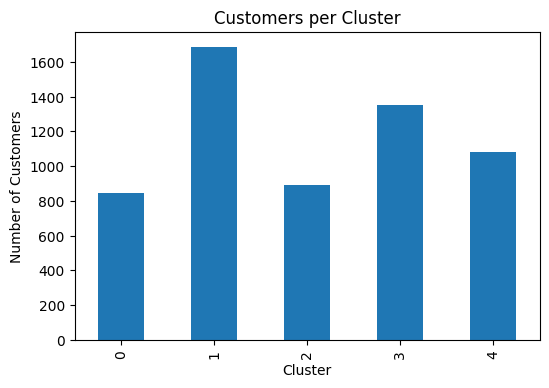

In [59]:
# Cluster size bar chart
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customers per Cluster')
plt.show()